In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [5]:
print("\n loading dataset..")
dataset=pd.read_csv("spam.csv",encoding="latin1")
print("dataset loaded sucessfully")


 loading dataset..
dataset loaded sucessfully


In [6]:
print("\n first five records")
print(dataset.head())


 first five records
  Category                                            Message Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [7]:
print("\n dataset information")
dataset.info()
print("\n dataset shape")
print(dataset.shape)


 dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Category    5572 non-null   object
 1   Message     5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB

 dataset shape
(5572, 5)


In [8]:
print("\n missing values")
print(dataset.isnull().sum())


 missing values
Category         0
Message          0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [11]:
print("\n email category count")
print(dataset["Category"].value_counts())


 email category count
Category
ham     4825
spam     747
Name: count, dtype: int64


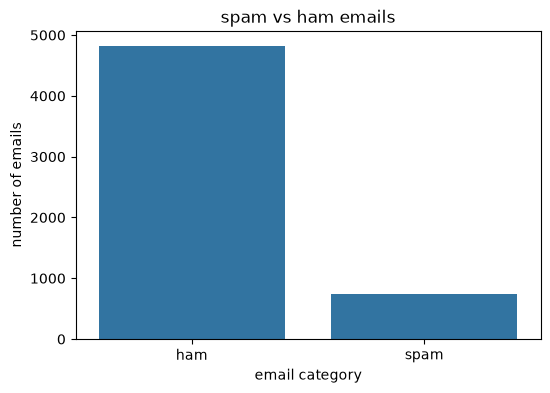

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="Category",data=dataset)
plt.title("spam vs ham emails")
plt.xlabel("email category")
plt.ylabel("number of emails")
plt.show()

In [15]:
x=dataset["Message"]
y=dataset["Category"]

In [17]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)
print("\n training samples:",len(x_train))
print("testing samples:",len(x_test))


 training samples: 4457
testing samples: 1115


In [18]:
print("\n converting text into numerical features...")
cv=CountVectorizer()
x_train=cv.fit_transform(x_train)
x_test=cv.transform(x_test)
print("conversion completed")
print("training data shape:",x_train.shape)
print("testing data shape:",x_test.shape)


 converting text into numerical features...
conversion completed
training data shape: (4457, 7691)
testing data shape: (1115, 7691)


In [19]:
print("\n Training SVM Model..")
classifier=SVC(kernel="linear")
classifier.fit(x_train,y_train) 
print("model Training Completed")


 Training SVM Model..
model Training Completed


In [20]:
print("\npredicting Test data...")
y_pred=classifier.predict(x_test)
print("prediction completed")


predicting Test data...
prediction completed


In [21]:
accuracy=accuracy_score(y_test,y_pred)
print("MODEL ACCURACY")
print("accuracy=",accuracy)
print("accuracy={:.2f}%".format(accuracy*100))

MODEL ACCURACY
accuracy= 0.979372197309417
accuracy=97.94%



 confusion matrix
[[962   3]
 [ 20 130]]


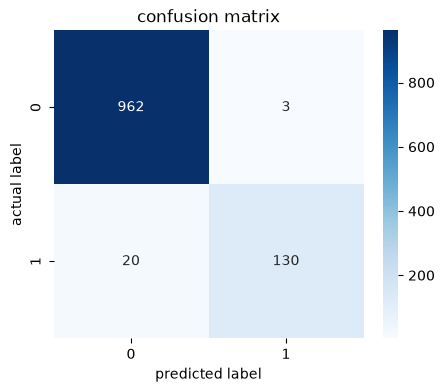

In [24]:
cm=confusion_matrix(y_test,y_pred)
print("\n confusion matrix")
print(cm)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("predicted label")
plt.ylabel("actual label")
plt.title("confusion matrix")
plt.show()

In [25]:
print("\n classification report")
print(classification_report(y_test,y_pred))


 classification report
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.98      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [27]:
print("Sample Predictions")
sample_messages = [
 "Congratulations! You have won a free iPhone. Click here to claim.",
 "Hi, Shall we meet tomorrow at 10 AM?",
 "URGENT! Your bank account has been suspended. Verify immediately.",
 "Happy Birthday! Have a wonderful day.",
 "You have won Rs.50000 cash prize. Call now."
]
sample_data = cv.transform(sample_messages)
predictions = classifier.predict(sample_data)
for message,prediction in zip(sample_messages,predictions):
 print("\nMessage :")
 print(message)
 print("Prediction :",prediction)

Sample Predictions

Message :
Congratulations! You have won a free iPhone. Click here to claim.
Prediction : spam

Message :
Hi, Shall we meet tomorrow at 10 AM?
Prediction : ham

Message :
URGENT! Your bank account has been suspended. Verify immediately.
Prediction : spam

Message :
Happy Birthday! Have a wonderful day.
Prediction : ham

Message :
You have won Rs.50000 cash prize. Call now.
Prediction : spam
